In [10]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [11]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params_mult
from src.MultiVariateForecaster import MultiVariateForecaster
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [12]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    if not y_pred.index.equals(y_true.index):
        y_pred.index = y_true.index
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    col = target_cols[0]
    lags_dict = {c: None for c in target_cols}
    lags_dict[col] = best_params[f'lags_{col}']
    models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
    
    for i in range(1, len(target_cols)):
        col = target_cols[i]
        neighbor_col = target_cols[i - 1]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))
        
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [13]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [14]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [15]:
model_path = f'../xgboost/models/xgb_v4'
target_cols = ['48-1 (0)', '48-1 (3)', '48-1 (5)', '48-1 (7)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [16]:
study = search_params_mult(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-14 19:09:56,708] A new study created in memory with name: no-name-0c286eae-54e1-4463-a9a5-d60094740864
[I 2026-05-14 19:10:01,170] Trial 0 finished with value: 0.3770242398103873 and parameters: {'n_estimators': 940, 'learning_rate': 0.05527906465701069, 'max_depth': 7, 'subsample': 0.9287014268754036, 'colsample_bytree': 0.5579736116293869, 'colsample_bylevel': 0.7107927365979224, 'colsample_bynode': 0.9731779381068155, 'reg_alpha': 0.0003909912043303152, 'reg_lambda': 0.0002972707892309538, 'gamma': 0.0018510047389550734, 'min_child_weight': 6, 'max_delta_step': 4, 'lags_48-1 (0)': 5, 'lags_48-1 (3)': 4, 'neighbor_lags_48-1 (3)': 3, 'lags_48-1 (5)': 4, 'neighbor_lags_48-1 (5)': 2, 'lags_48-1 (7)': 3, 'neighbor_lags_48-1 (7)': 3, 'lags_48-1 (10)': 4, 'neighbor_lags_48-1 (10)': 3}. Best is trial 0 with value: 0.3770242398103873.
[I 2026-05-14 19:10:05,111] Trial 1 finished with value: 0.9392475018429107 and parameters: {'n_estimators': 544, 'learning_rate': 0.001139580106660

Лучшие параметры = {'n_estimators': 304, 'learning_rate': 0.0178420307636356, 'max_depth': 9, 'subsample': 0.8429059827609982, 'colsample_bytree': 0.5476920045098392, 'colsample_bylevel': 0.5520501986545612, 'colsample_bynode': 0.8860318555677152, 'reg_alpha': 0.0017715133760301475, 'reg_lambda': 0.0020084247348306126, 'gamma': 5.130228503399455e-05, 'min_child_weight': 12, 'max_delta_step': 11, 'lags_48-1 (0)': 5, 'lags_48-1 (3)': 4, 'neighbor_lags_48-1 (3)': 1, 'lags_48-1 (5)': 5, 'neighbor_lags_48-1 (5)': 2, 'lags_48-1 (7)': 3, 'neighbor_lags_48-1 (7)': 1, 'lags_48-1 (10)': 5, 'neighbor_lags_48-1 (10)': 3}
Лучший RMSE score = 0.3649943996310493


In [17]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v4']

48-1 (0)
RMSE на тесте = 2.942268665436738


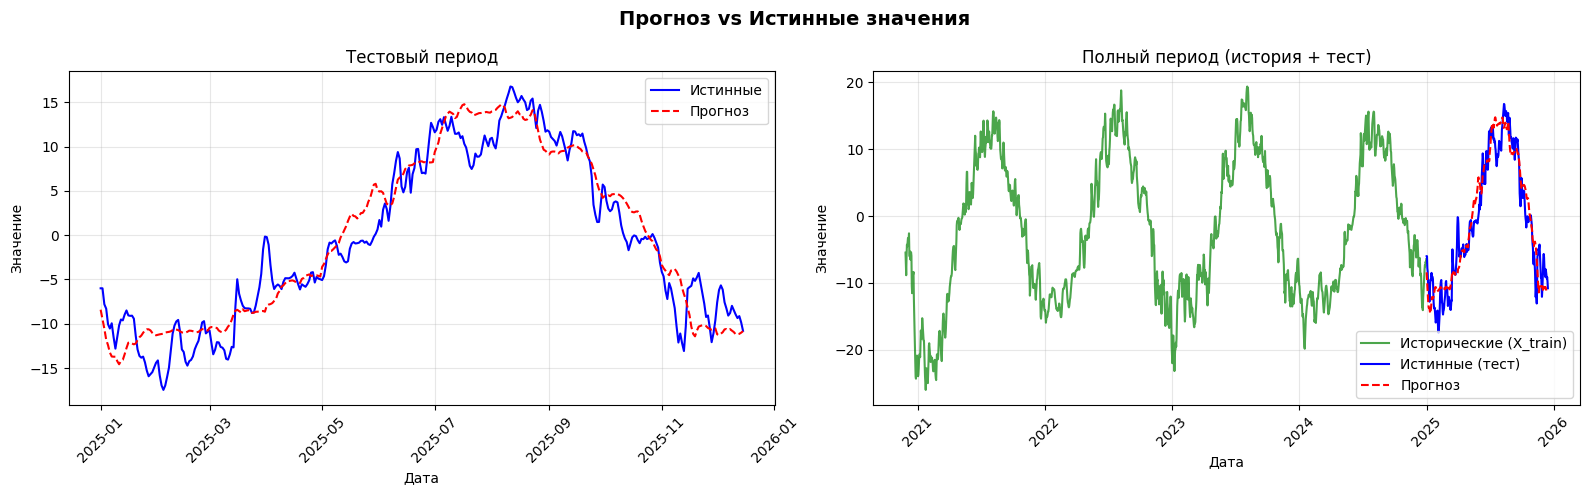

           feature  importance
6        Месяц_cos    0.249688
0   48-1 (0)_lag_1    0.130539
3   48-1 (0)_lag_4    0.114706
4   48-1 (0)_lag_5    0.113891
1   48-1 (0)_lag_2    0.107547
2   48-1 (0)_lag_3    0.093962
8  day_of_year_cos    0.092712
5        Месяц_sin    0.058204
7  day_of_year_sin    0.038751
48-1 (3)
RMSE на тесте = 1.0199698539959847


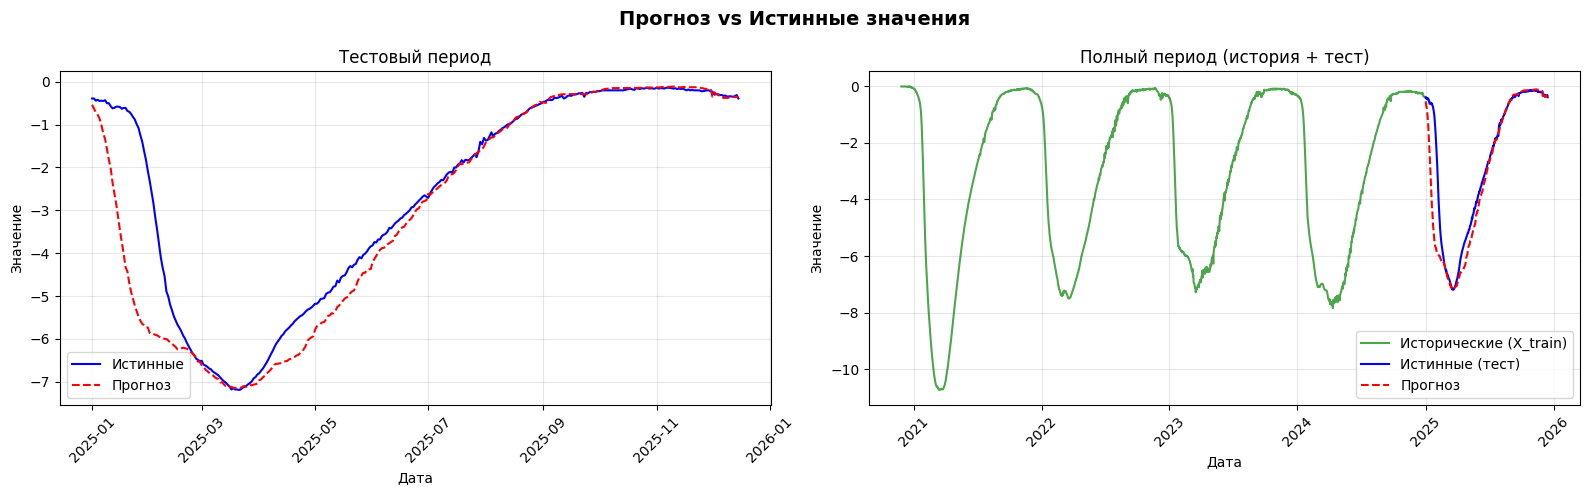

           feature  importance
5        Месяц_sin    0.266144
2   48-1 (3)_lag_2    0.191357
4   48-1 (3)_lag_4    0.153100
1   48-1 (3)_lag_1    0.134018
3   48-1 (3)_lag_3    0.090706
7  day_of_year_sin    0.080783
6        Месяц_cos    0.033636
0   48-1 (0)_lag_1    0.028548
8  day_of_year_cos    0.021708
48-1 (5)
RMSE на тесте = 0.5177746808640634


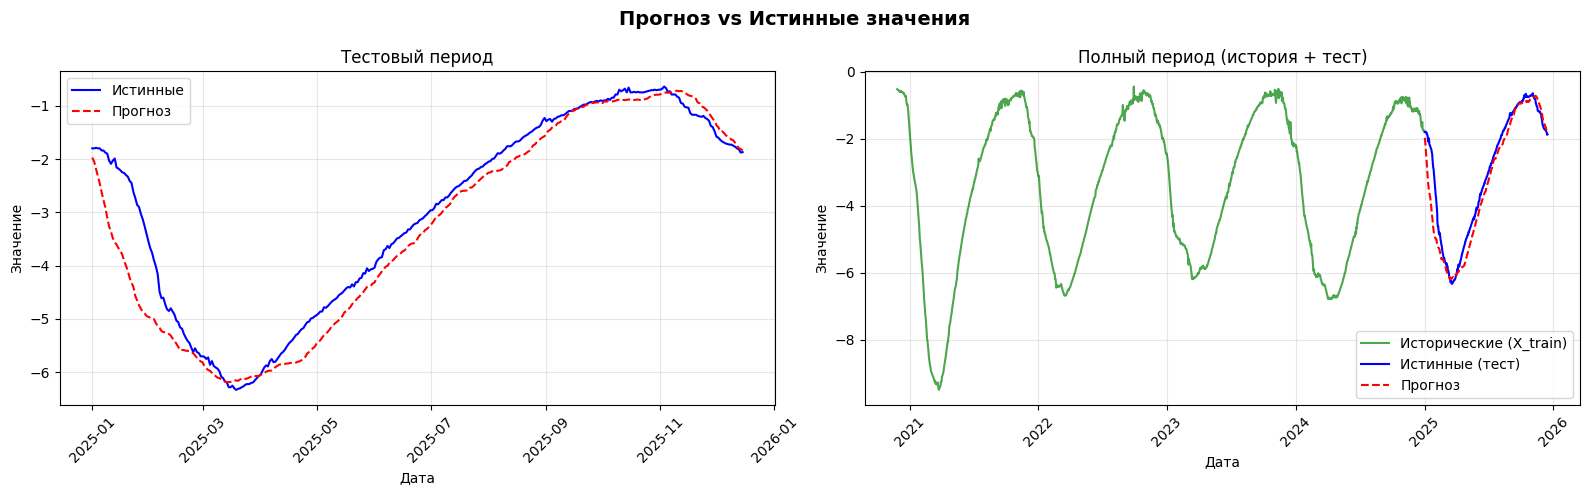

            feature  importance
7         Месяц_sin    0.212423
4    48-1 (5)_lag_3    0.148903
2    48-1 (5)_lag_1    0.136877
3    48-1 (5)_lag_2    0.117507
6    48-1 (5)_lag_5    0.109199
1    48-1 (3)_lag_2    0.073962
5    48-1 (5)_lag_4    0.071918
0    48-1 (3)_lag_1    0.057487
9   day_of_year_sin    0.045899
8         Месяц_cos    0.022903
10  day_of_year_cos    0.002920
48-1 (7)
RMSE на тесте = 0.47166258428918845


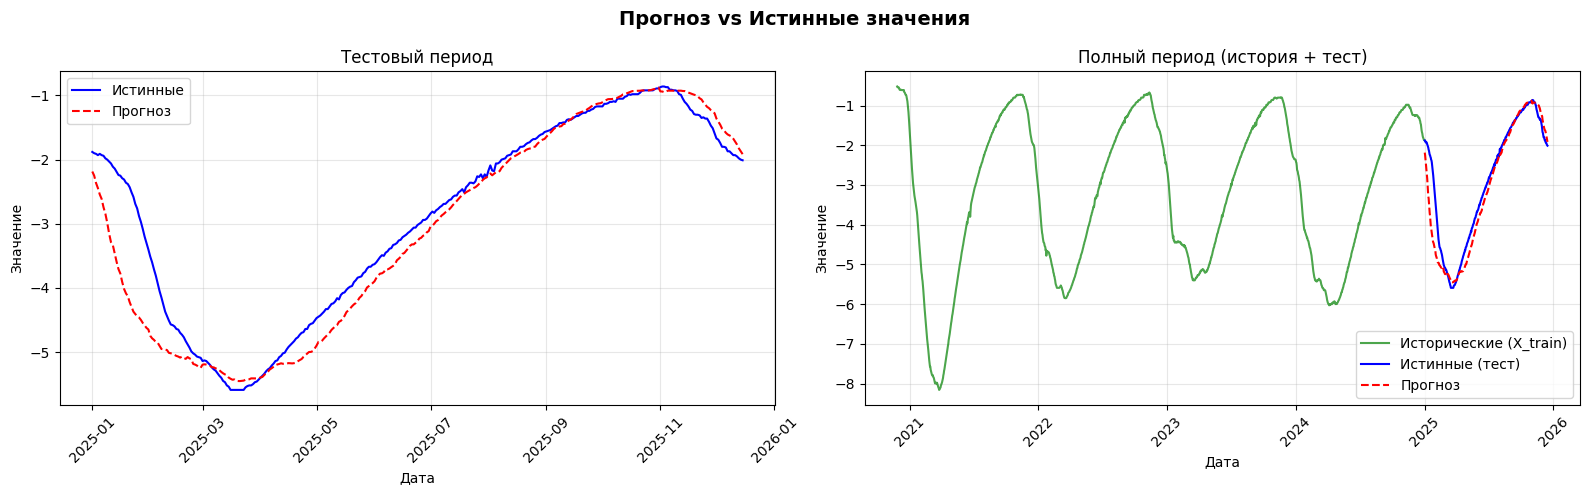

           feature  importance
4        Месяц_sin    0.274479
2   48-1 (7)_lag_2    0.168365
1   48-1 (7)_lag_1    0.149010
3   48-1 (7)_lag_3    0.134362
6  day_of_year_sin    0.126712
0   48-1 (5)_lag_1    0.100292
7  day_of_year_cos    0.023489
5        Месяц_cos    0.023291
48-1 (10)
RMSE на тесте = 0.1913144784571366


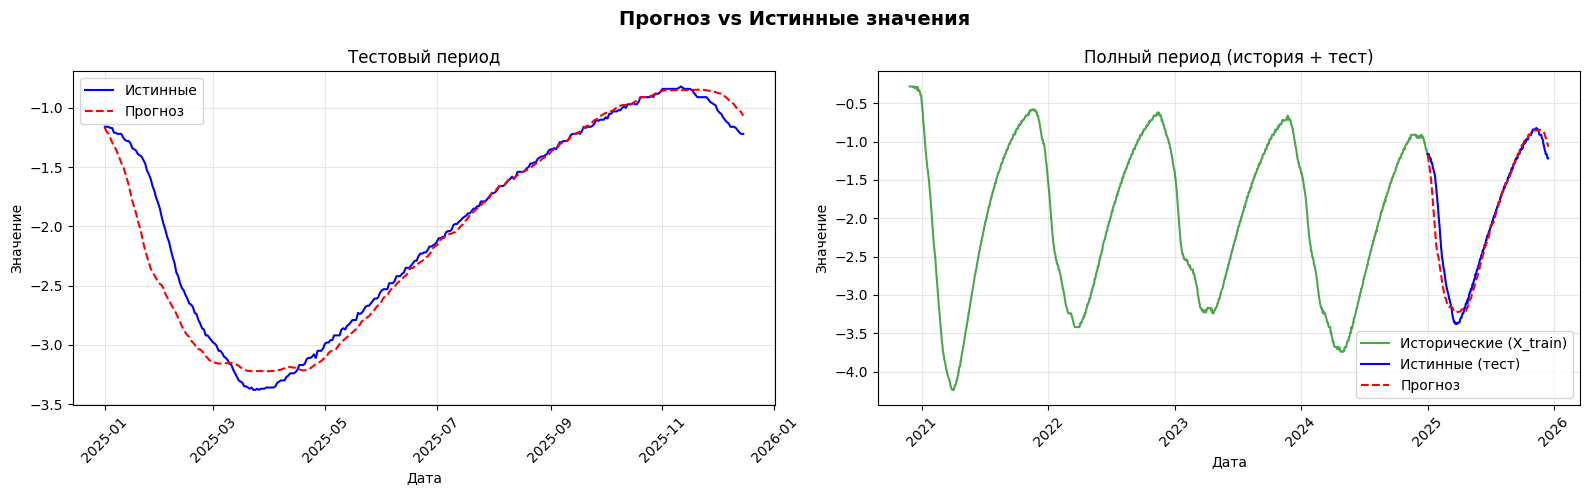

            feature  importance
7   48-1 (10)_lag_5    0.146194
4   48-1 (10)_lag_2    0.144949
8         Месяц_sin    0.131816
6   48-1 (10)_lag_4    0.131332
5   48-1 (10)_lag_3    0.099809
10  day_of_year_sin    0.090342
3   48-1 (10)_lag_1    0.074558
1    48-1 (7)_lag_2    0.069716
0    48-1 (7)_lag_1    0.054192
2    48-1 (7)_lag_3    0.041231
11  day_of_year_cos    0.011028
9         Месяц_cos    0.004832


In [18]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
for col in target_cols:
    print(col)
    y_pred = predicts[col]
    y_true = df_test[col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE на тесте = {rmse}')
    
    plot_forecast(df_train_full[col], y_true, y_pred)
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)